In [1]:

import anndata as ad
import celltypist
from celltypist import models
import scanpy as sc
import numpy as np
import os.path as op
np.random.seed(12)

/data_nfs/og86asub/netmap/netmap-evaluation/netmap/.pixi/envs/default/lib/python3.12/site-packages/celltypist/classifier.py:11: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  from scanpy import __version__ as scv


In [2]:
adata = sc.read_h5ad('/data_nfs/og86asub/netmap/netmap-evaluation/data/blood/SRR/kallisto/mtx_conversions/10x_rep1/10x_rep1_cellbender_filter_matrix.h5ad')


In [3]:
adata.var = adata.var.reset_index()
adata.var = adata.var.set_index("gene_symbol")
adata.var.index = adata.var.index.astype(str)
adata.var_names_make_unique()


In [4]:

# mitochondrial genes, "MT-" for human, "Mt-" for mouse
adata.var["mt"] = adata.var_names.str.startswith("MT-")
# ribosomal genes
adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
# hemoglobin genes
adata.var["hb"] = adata.var_names.str.contains("^HB[^(P)]")

sc.pp.calculate_qc_metrics(adata, qc_vars=["mt", "ribo", "hb"], inplace=True, log1p=True)

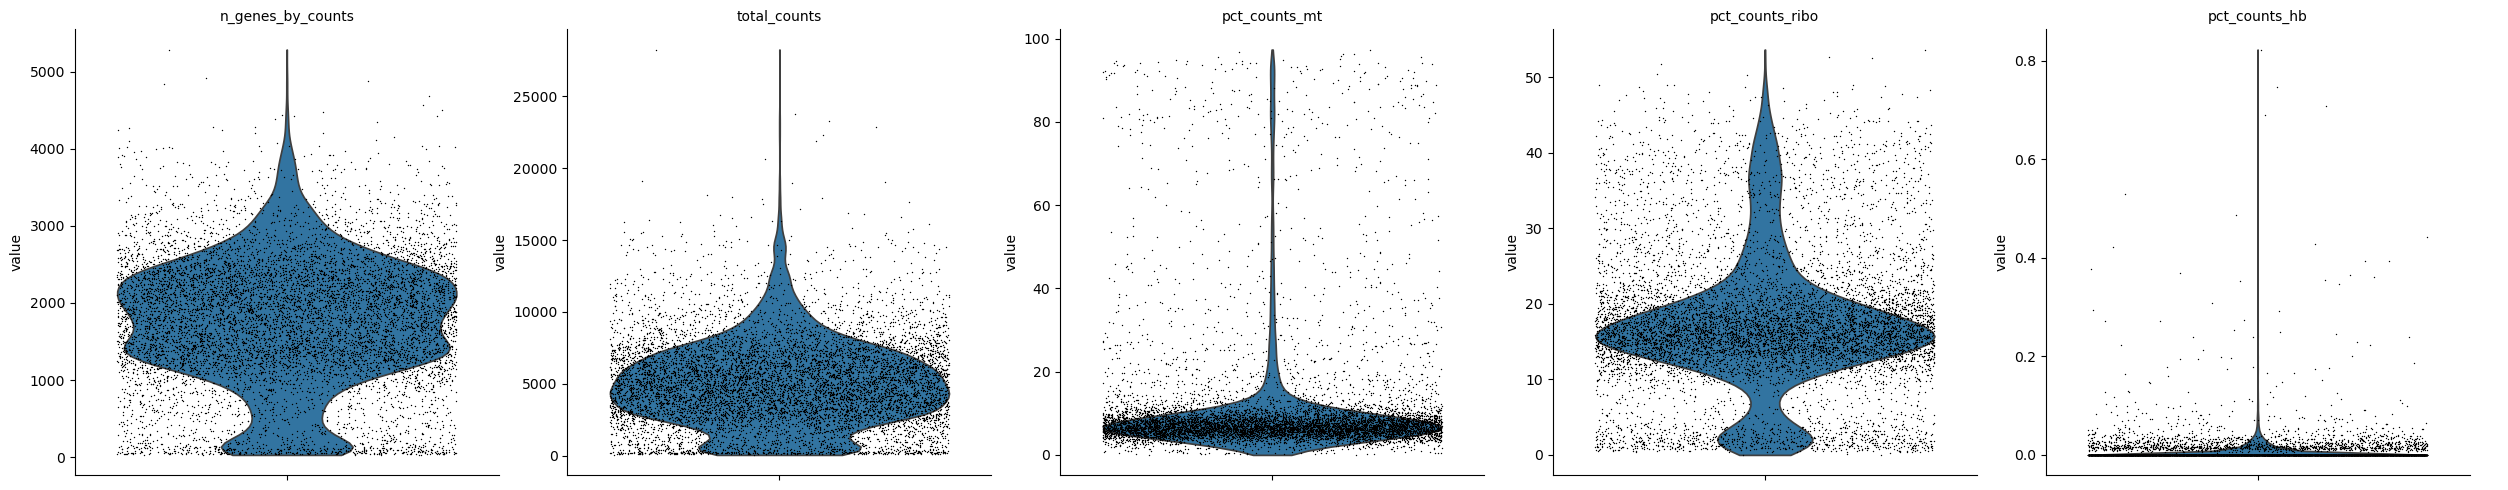

In [5]:
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt", 'pct_counts_ribo', 'pct_counts_hb'],
    jitter=0.4,
    multi_panel=True,
)

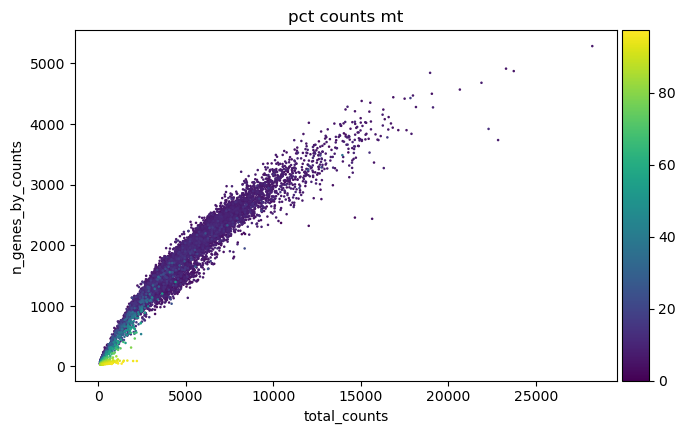

In [6]:
sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

In [7]:
sc.pp.filter_cells(adata, min_genes=500)
sc.pp.filter_genes(adata, min_cells=50)
adata = adata[adata.obs.pct_counts_mt<20]

In [8]:
sc.pp.scrublet(adata)


In [9]:
adata.layers["counts"] = adata.X.copy()
sc.pp.scale(adata)

In [10]:
sc.pp.highly_variable_genes(adata, n_top_genes=2500)
sc.pp.pca(adata)
sc.pp.neighbors(adata)
sc.tl.leiden(adata, resolution=0.45)

sc.tl.umap(adata)

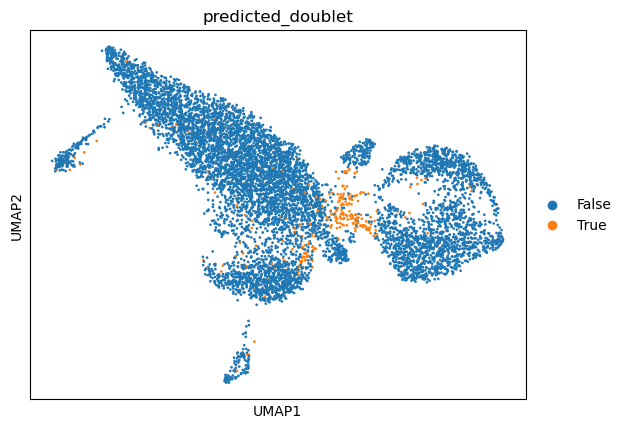

In [11]:
sc.pl.umap(adata, color = 'predicted_doublet')

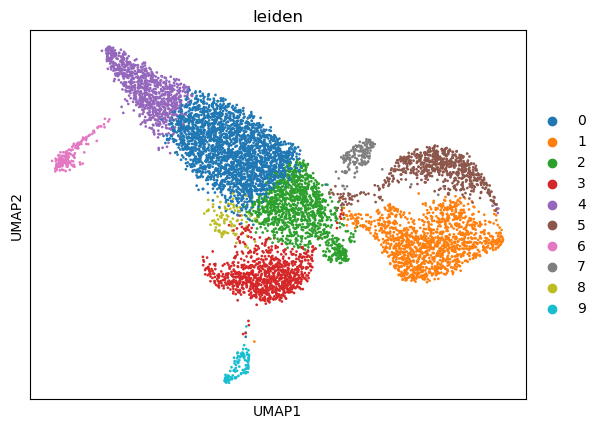

In [12]:
sc.pl.umap(adata, color = 'leiden')

In [13]:
adata = adata[adata.obs.predicted_doublet == False]


In [14]:
adata.X

ArrayView([[ 4.2420819 , -0.19238248, -0.18169949, ..., -0.14992724,
            -0.09487373, -0.11826033],
           [-0.21919572,  4.62201939, -0.18169949, ..., -0.14992724,
            -0.09487373, -0.11826033],
           [-0.21919572, -0.19238248,  5.11487388, ..., -0.14992724,
            -0.09487373, -0.11826033],
           ...,
           [-0.21919572, -0.19238248, -0.18169949, ..., -0.14992724,
            -0.09487373, -0.11826033],
           [-0.21919572, -0.19238248, -0.18169949, ..., -0.14992724,
            -0.09487373, -0.11826033],
           [-0.21919572, -0.19238248, -0.18169949, ..., -0.14992724,
            -0.09487373, -0.11826033]], shape=(7685, 13715))

In [15]:
# Saving count data


In [ ]:
# Normalizing to median total counts
sc.pp.normalize_total(adata, target_sum = 10000)
adata.layers['count_norm'] = adata.X.copy()
# Logarithmize the data
sc.pp.log1p(adata)

In [17]:
models.download_models(model = 'Immune_All_Low.pkl', force_update = True)
model = models.Model.load(model = 'Immune_All_High.pkl')
predictions = celltypist.annotate(adata, model = 'Immune_All_High.pkl', majority_voting = True)

📜 Retrieving model list from server https://celltypist.cog.sanger.ac.uk/models/models.json
📚 Total models in list: 61
📂 Storing models in /data/og86asub/.celltypist/data/models
💾 Total models to download: 1
💾 Downloading model [1/1]: Immune_All_Low.pkl
🔬 Input data has 7685 cells and 13715 genes
🔗 Matching reference genes in the model
🧬 4221 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels


ValueError: Input X contains NaN.
LogisticRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [14]:
adata = predictions.to_adata()
adata.obs.majority_voting.value_counts()

majority_voting
Monocytes                   5194
T cells                     1260
ILC                          616
DC                           244
pDC                          151
B cells                      144
Megakaryocytes/platelets      76
Name: count, dtype: int64

In [15]:
model = models.Model.load(model = 'Immune_All_Low.pkl')
predictions = celltypist.annotate(adata, model = 'Immune_All_Low.pkl', majority_voting = True)

🔬 Input data has 7685 cells and 13715 genes


🔗 Matching reference genes in the model
🧬 4221 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
👀 Detected a neighborhood graph in the input object, will run over-clustering on the basis of it
⛓️ Over-clustering input data with resolution set to 10
🗳️ Majority voting the predictions
✅ Majority voting done!


In [16]:
adata.obs['granular']= predictions.predicted_labels['predicted_labels']

In [ ]:
sc.pp.highly_variable_genes(adata, n_top_genes=2500)
sc.pp.pca(adata)
sc.pp.neighbors(adata)
sc.tl.leiden(adata, resolution=0.45)

sc.tl.umap(adata)

In [2]:
sc.pl.umap(adata, color = [ 'predicted_labels', 'majority_voting' , 'leiden', 'CD14', 'CD4', 'granular'])

NameError: name 'sc' is not defined

In [ ]:
celltype_mapping_2 = {
    '0': 'cd14+_monocytes',
    '1': 'cd14+_monocytes',
    '2': 'cd14-_monocytes',
    '3': 'cd4+_tcells',
    '4':  'nk_cells',
    '5': 'cd8+_tcells',
    '6': 'DC',
    '7': 'pDC',
    '8': 'b_cells',
    '9': 'megakaryocytes'}

In [25]:
adata.obs['celltype_semi_manual'] = [celltype_mapping_2[c] for c in adata.obs['leiden']]


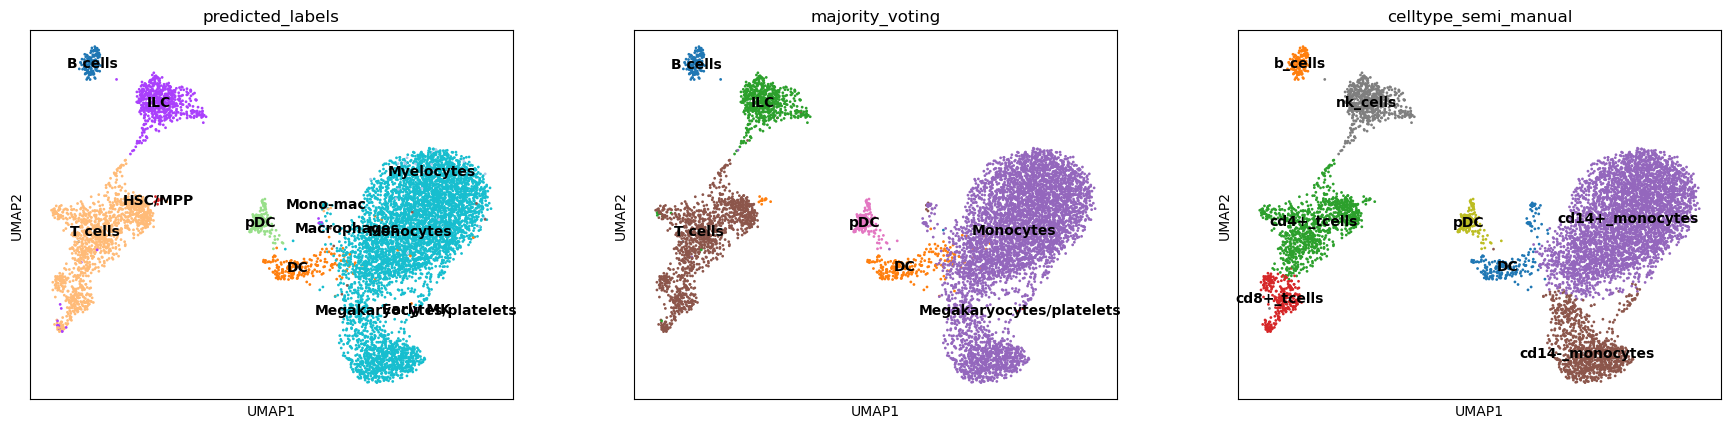

In [40]:
sc.pl.umap(adata, color = [ 'predicted_labels', 'majority_voting', 'celltype_semi_manual'], legend_loc = 'on data')

In [41]:
experiment_id = '10x-rep1-kallisto-cellbender'
output_dir = f'/data_nfs/og86asub/teaching/{experiment_id}'
import os
os.makedirs(output_dir, exist_ok = True)
adata.obs.loc[:, ['celltype_semi_manual']].reset_index().to_csv(op.join(output_dir, 'barcode_annotation.tsv'), sep = '\t')

In [32]:

adata.X = np.nan_to_num(adata.X) 
adata.X[adata.X == np.inf] = 0
adata.X[adata.X == -np.inf] = 0



In [33]:
import pandas as pd
pangalao = pd.read_csv('/data_nfs/og86asub/netmap/netmap-evaluation/data/markers/panglaodb_human.csv')
high_ui = pangalao[pangalao['UI']>0.1]['Official gene symbol'].values
adata = adata[:, ~adata.var.index.isin(high_ui)].copy()

In [35]:
adata = adata[:, adata.var.highly_variable].copy()
adata = adata[:,adata.var.pct_dropout_by_counts<95].copy()
adata

AnnData object with n_obs × n_vars = 7685 × 989
    obs: 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'doublet_score', 'predicted_doublet', 'predicted_labels', 'majority_voting', 'conf_score', 'granular', 'leiden', 'celltype_semi_manual'
    var: 'index', 'gene_versions', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'scrublet', 'log1p', 'neighbors', 'over_clustering', 'hvg', 'pca', 'leiden', 'umap', 'predicted_labels_colors', 'majority_voting_co

In [37]:
adata.obs.celltype_semi_manual.value_counts()
adata = adata[adata.obs.celltype_semi_manual != 'megakaryocytes'].copy()

In [38]:
adata.write_h5ad(op.join(output_dir, f'{experiment_id}.h5ad'))

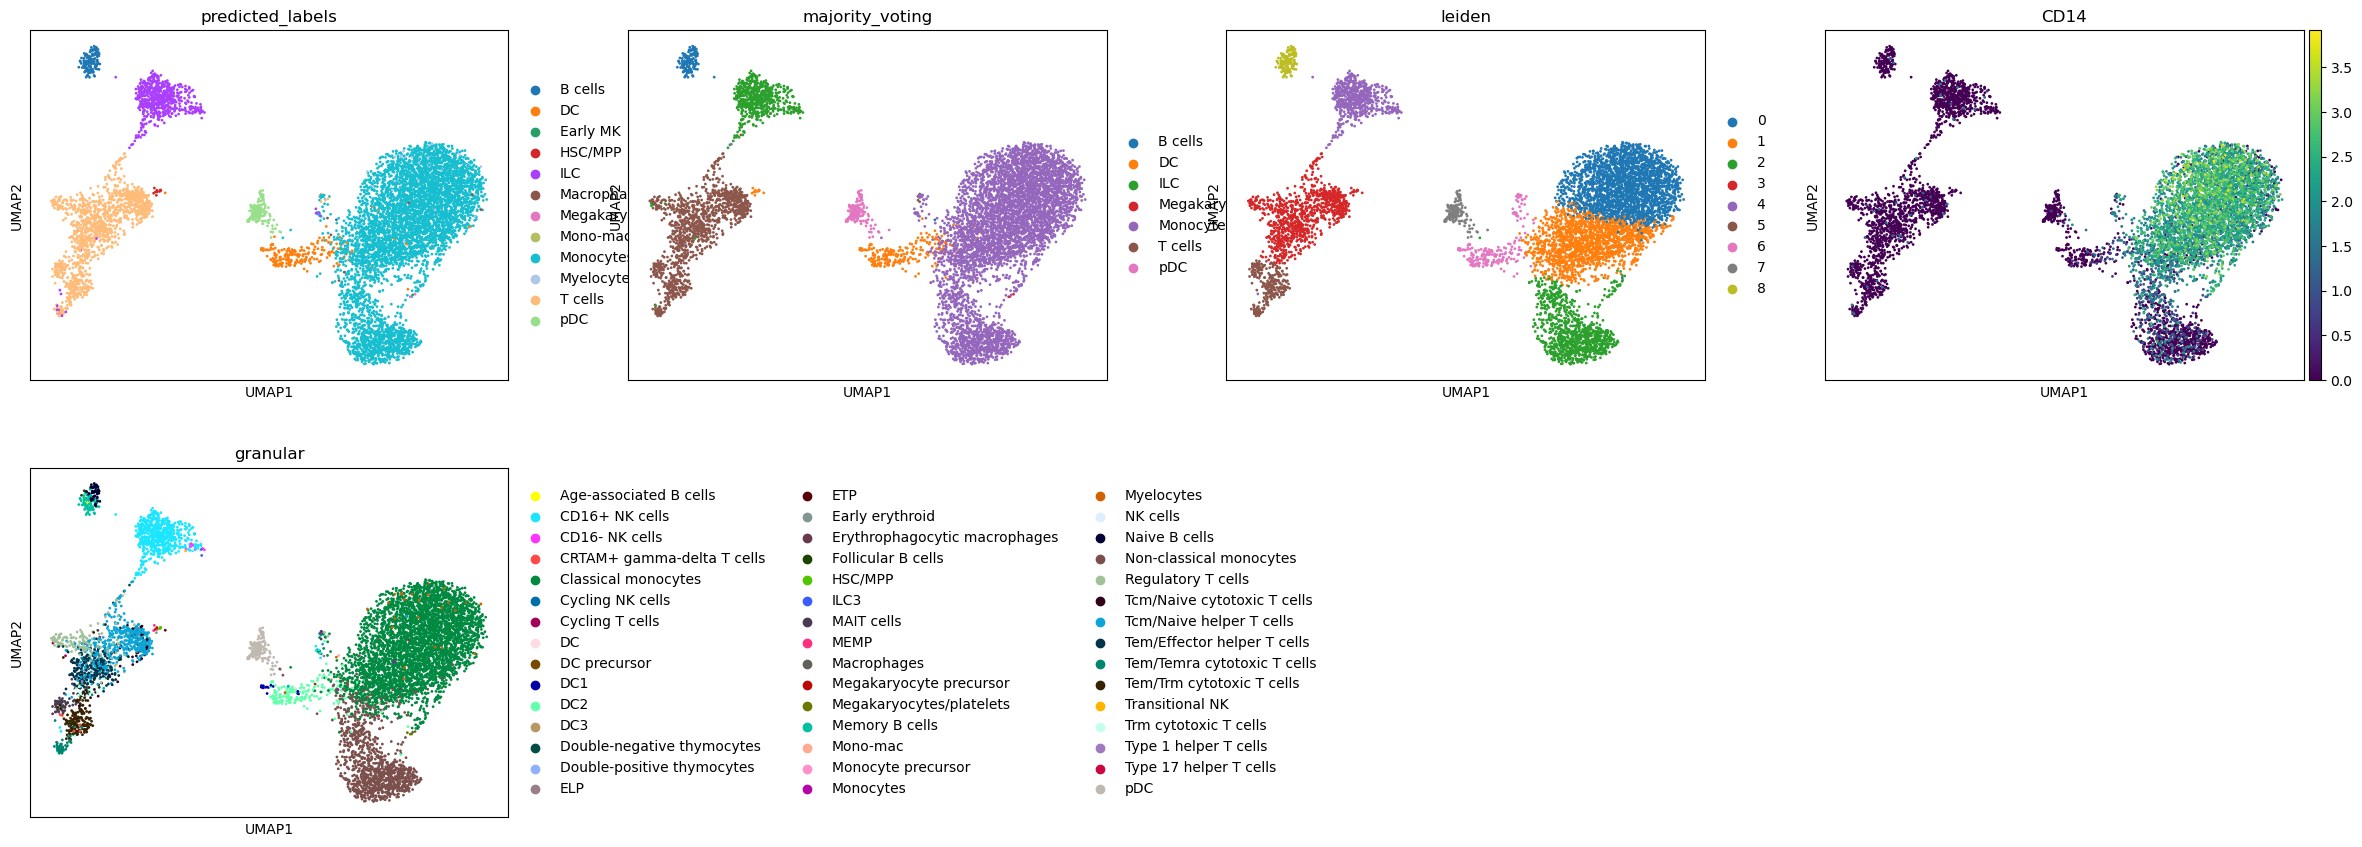

In [39]:
sc.pl.umap(adata, color = [ 'predicted_labels', 'majority_voting' , 'leiden', 'CD14', 'granular'])